<a href="https://colab.research.google.com/github/liscano2/ALBERTO-EPIDEMIOLOGIA/blob/main/albertoepidemiologiajulio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline RAM Magdalena — Parte 2: Análisis Exploratorio de Datos (EDA)

**Entrada:** `base_pretratada_RAM_Magdalena.xlsx` (hoja `datos_aislamientos`, 1590 aislamientos × 58 columnas).
**Objetivo de esta parte:** conocer la estructura, calidad y distribución de los datos antes de construir los análisis del artículo — completitud, distribuciones, y outliers.

> Sube el archivo `base_pretratada_RAM_Magdalena.xlsx` a Colab (panel izquierdo o `files.upload()`) antes de correr la sección 1.

---


In [38]:
## 0. Configuración e importación

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110





In [48]:
from google.colab import files
print("Selecciona base_pretratada_RAM_Magdalena.xlsx:")
archivo_subido = files.upload()
RUTA_BASE = list(archivo_subido.keys())[0]

df_base_pretratada = pd.read_excel(RUTA_BASE, sheet_name="datos_aislamientos")

# Verificación de que se cargó el archivo correcto (no una hoja cruda)
columnas_esperadas = {"anio", "mes", "microorganismo", "servicio", "area_uci", "MDR", "n_testeados"}
faltantes = columnas_esperadas - set(df_base_pretratada.columns)
if faltantes:
    raise ValueError(
        f"El archivo cargado NO es la base pretratada correcta. Faltan columnas: {faltantes}.\n"
        f"Verifica que subiste 'base_pretratada_RAM_Magdalena.xlsx' (no uno de los archivos originales)\n"
        f"y que la hoja se llama 'datos_aislamientos'."
    )

print("✓ Archivo correcto verificado.")
print("Filas:", df_base_pretratada.shape[0], "| Columnas:", df_base_pretratada.shape[1])
df_base_pretratada.head()

Selecciona base_pretratada_RAM_Magdalena.xlsx:


Saving base_pretratada_RAM_Magdalena.xlsx to base_pretratada_RAM_Magdalena (3).xlsx
✓ Archivo correcto verificado.
Filas: 1590 | Columnas: 58


,num_muestra,id_paciente,anio,mes,fecha,microorganismo,micro_cod,tipo_microorg,servicio,servicio_raw,area_uci,poblacion,tipo_muestra,n_testeados,n_resistentes,n_sensibles,n_intermedios,pct_resistencia,n_clases_resistentes,MDR,CZA,CZT,AMK,AMP,CEP,CZO,FEP,CPT,CAZ,CIP,CLI,SAM,DAP,ERY,ETP,STH,FOS,GEN,GEH,IPM,LNZ,NIT,OXA,PEN,TZP,RIF,TCY,SXT,VAN,LVX,MEM,ATM,CRO,TGC,CAS,FLU,VOR,CTX
0,0265401-HC1,10435109,2023,8,2023-08-29,Acinetobacter baumannii,aba,Gram negativo,Servicio Quirúrgico,s.qx,No UCI,No especificada,Sangre/Hemocultivo,8,1,7,0,12.5,1,No MDR,NaN,NaN,S,NaN,NaN,R,NaN,NaN,S,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,S,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0215515-OC,1081802952,2023,3,2023-03-21,Acinetobacter baumannii,aba,Gram negativo,Urgencias Adultos,urg ad,No UCI,Adultos,Orina,8,1,7,0,12.5,1,No MDR,NaN,NaN,S,NaN,NaN,R,NaN,NaN,S,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,S,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0278013-HC1,1081827970,2023,10,2023-10-07,Acinetobacter baumannii,aba,Gram negativo,UCI Adultos,uci ad,UCI,Adultos,Sangre/Hemocultivo,8,1,7,0,12.5,1,No MDR,NaN,NaN,S,NaN,NaN,R,NaN,NaN,S,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,S,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0272074-MV,1221984903,2023,9,2023-09-19,Acinetobacter baumannii,aba,Gram negativo,Hospitalización Pediátrica,hosped,No UCI,Pediátrica/Neonatal,Sangre/Hemocultivo,8,1,7,0,12.5,1,No MDR,NaN,NaN,S,NaN,NaN,R,NaN,NaN,S,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,S,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0220298-HC1,230436104116,2023,4,2023-04-06,Acinetobacter baumannii,aba,Gram negativo,UCI Neonatal,ucine,UCI,Pediátrica/Neonatal,Sangre/Hemocultivo,8,1,7,0,12.5,1,No MDR,NaN,NaN,S,NaN,NaN,R,NaN,NaN,S,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,S,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Estructura general

In [49]:
df_base_pretratada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1590 entries, 0 to 1589
Data columns (total 58 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   num_muestra           1590 non-null   object        
 1   id_paciente           1590 non-null   object        
 2   anio                  1590 non-null   int64         
 3   mes                   1590 non-null   int64         
 4   fecha                 1590 non-null   datetime64[ns]
 5   microorganismo        1590 non-null   object        
 6   micro_cod             1590 non-null   object        
 7   tipo_microorg         1590 non-null   object        
 8   servicio              1589 non-null   object        
 9   servicio_raw          1589 non-null   object        
 10  area_uci              1590 non-null   object        
 11  poblacion             1590 non-null   object        
 12  tipo_muestra          1590 non-null   object        
 13  n_testeados       

In [50]:
# Columnas de antibiótico vs metadatos (se usa en toda la Parte 2 y en partes siguientes)
ANTIBIOTICOS = [c for c in df_base_pretratada.columns
                if c.isupper() and 2 <= len(c) <= 4 and c != "MDR"]
METADATOS = [c for c in df_base_pretratada.columns if c not in ANTIBIOTICOS]

print(f"Metadatos ({len(METADATOS)}):", METADATOS)
print(f"\nAntibióticos ({len(ANTIBIOTICOS)}):", ANTIBIOTICOS)

Metadatos (20): ['num_muestra', 'id_paciente', 'anio', 'mes', 'fecha', 'microorganismo', 'micro_cod', 'tipo_microorg', 'servicio', 'servicio_raw', 'area_uci', 'poblacion', 'tipo_muestra', 'n_testeados', 'n_resistentes', 'n_sensibles', 'n_intermedios', 'pct_resistencia', 'n_clases_resistentes', 'MDR']

Antibióticos (38): ['CZA', 'CZT', 'AMK', 'AMP', 'CEP', 'CZO', 'FEP', 'CPT', 'CAZ', 'CIP', 'CLI', 'SAM', 'DAP', 'ERY', 'ETP', 'STH', 'FOS', 'GEN', 'GEH', 'IPM', 'LNZ', 'NIT', 'OXA', 'PEN', 'TZP', 'RIF', 'TCY', 'SXT', 'VAN', 'LVX', 'MEM', 'ATM', 'CRO', 'TGC', 'CAS', 'FLU', 'VOR', 'CTX']


## 3. Completitud y datos faltantes

### 3.1 Faltantes en metadatos

In [51]:
faltantes_meta = df_base_pretratada[METADATOS].isna().sum()
faltantes_meta = faltantes_meta[faltantes_meta > 0].sort_values(ascending=False)
print("Metadatos con valores faltantes:")
print(faltantes_meta if len(faltantes_meta) else "Ninguno")

Metadatos con valores faltantes:
pct_resistencia    70
servicio            1
servicio_raw        1
dtype: int64


### 3.2 Faltantes en antibióticos (= "no testeado", no es un error)

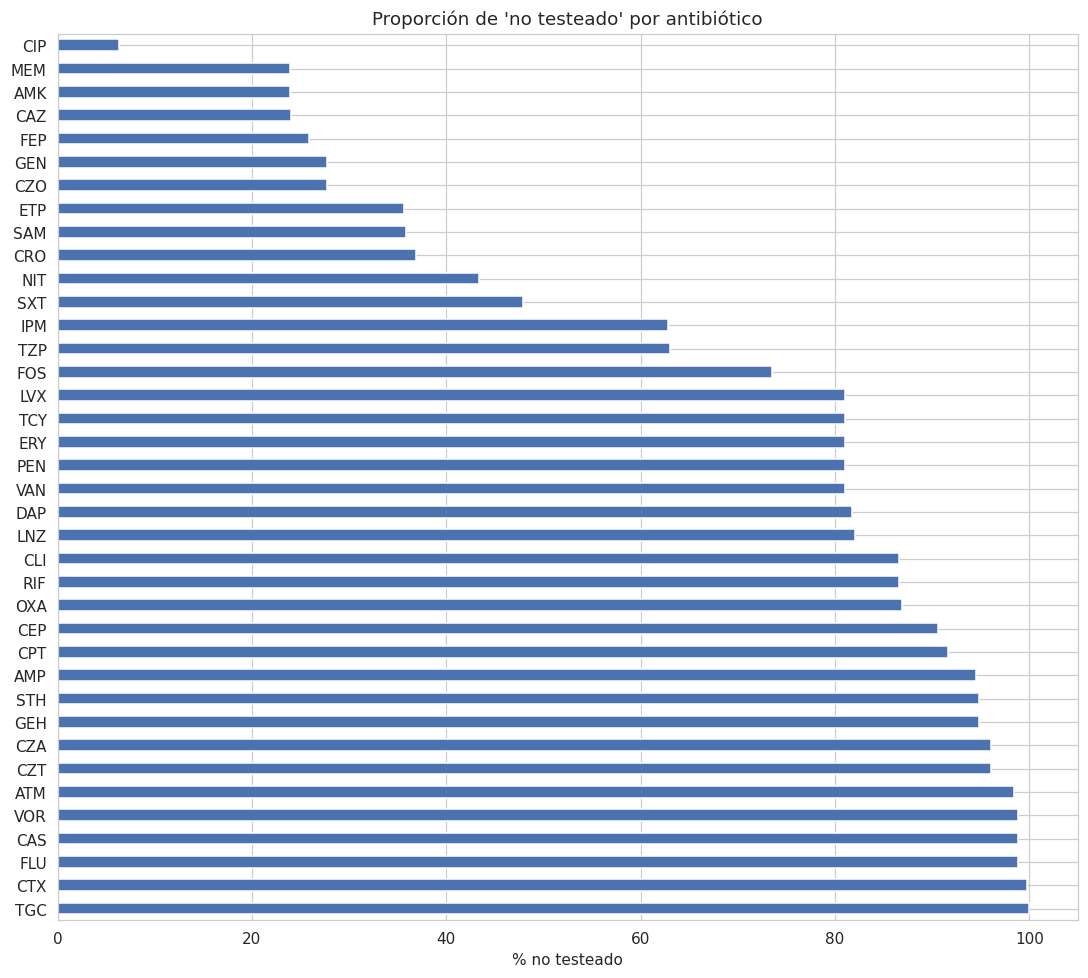

TGC    100.0
CTX     99.7
FLU     98.8
CAS     98.8
VOR     98.8
ATM     98.4
CZT     96.0
CZA     96.0
GEH     94.8
STH     94.8
AMP     94.5
CPT     91.6
CEP     90.6
OXA     86.9
RIF     86.6
CLI     86.6
LNZ     82.1
DAP     81.7
VAN     81.1
PEN     81.1
ERY     81.1
TCY     81.1
LVX     81.1
FOS     73.5
TZP     63.0
IPM     62.8
SXT     47.9
NIT     43.4
CRO     36.9
SAM     35.8
ETP     35.7
CZO     27.7
GEN     27.7
FEP     25.8
CAZ     24.0
AMK     24.0
MEM     24.0
CIP      6.4
dtype: float64


In [52]:
faltantes_ab = df_base_pretratada[ANTIBIOTICOS].isna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 9))
faltantes_ab.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("% no testeado")
ax.set_title("Proporción de 'no testeado' por antibiótico")
plt.tight_layout()
plt.show()

print(faltantes_ab.round(1))

### 3.3 Mapa de calor de completitud (patrón de testeo)

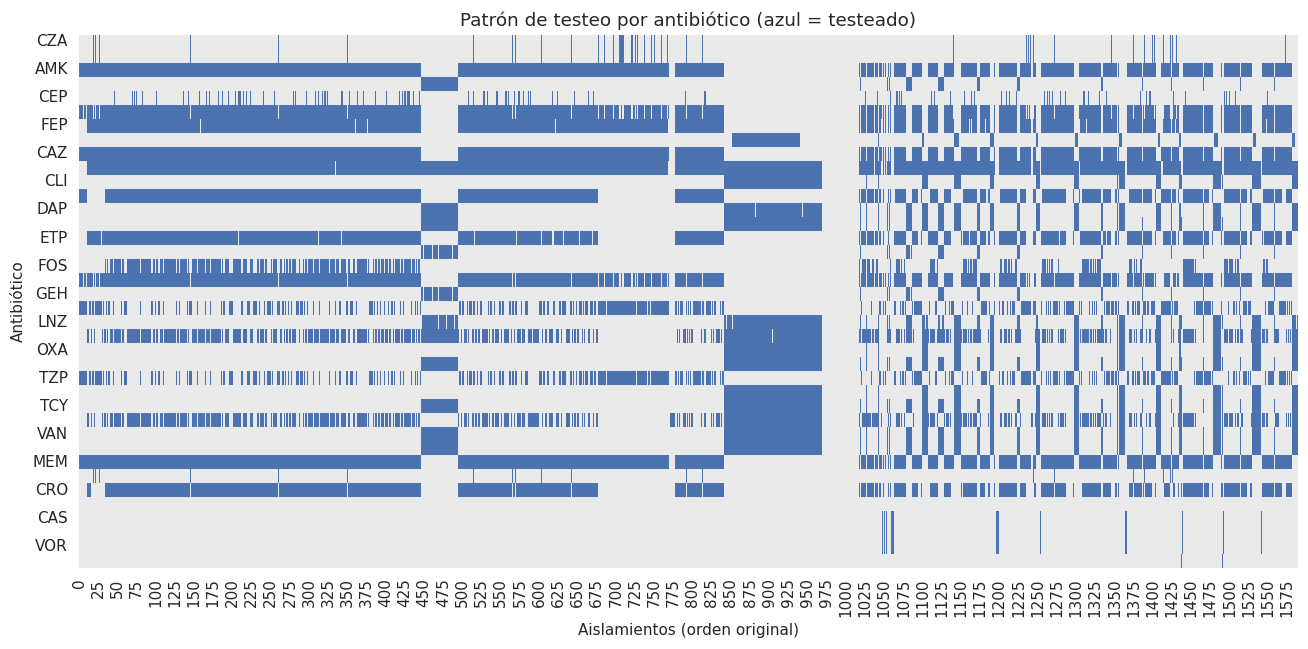

In [53]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(df_base_pretratada[ANTIBIOTICOS].notna().T, cbar=False,
            cmap=["#EAEAEA", "#4C72B0"], ax=ax)
ax.set_xlabel("Aislamientos (orden original)")
ax.set_ylabel("Antibiótico")
ax.set_title("Patrón de testeo por antibiótico (azul = testeado)")
plt.tight_layout()
plt.show()

## 4. Variables categóricas: distribución

### 4.1 Microorganismos

microorganismo
Escherichia coli                650
Klebsiella pneumoniae           282
Pseudomonas aeruginosa          150
Staphylococcus aureus           137
Proteus mirabilis                94
Enterococcus faecalis            89
Staphylococcus epidermidis       60
Enterobacter cloacae             27
Candida albicans                 19
Staphylococcus saprophyticus     18
Acinetobacter baumannii          15
Stenotrophomonas maltophilia     11
Enterobacter aerogenes           10
Salmonella spp.                   9
Proteus vulgaris                  4
Serratia marcescens               4
Streptococcus pneumoniae          4
Morganella morganii               3
Enterococcus faecium              2
Citrobacter freundii              1
Salmonella Typhi                  1
Name: count, dtype: int64


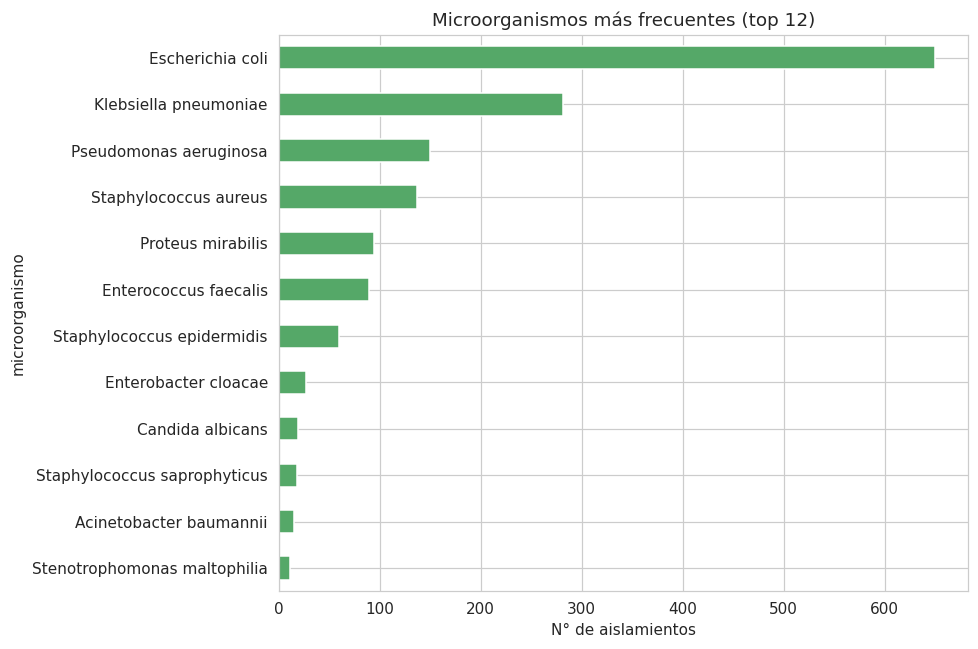

In [56]:
top_micro = df_base_pretratada["microorganismo"].value_counts()
print(top_micro)

fig, ax = plt.subplots(figsize=(9, 6))
top_micro.head(12).plot(kind="barh", ax=ax, color="#55A868")
ax.invert_yaxis()
ax.set_xlabel("N° de aislamientos")
ax.set_title("Microorganismos más frecuentes (top 12)")
plt.tight_layout()
plt.show()

### 4.2 Servicio y área UCI

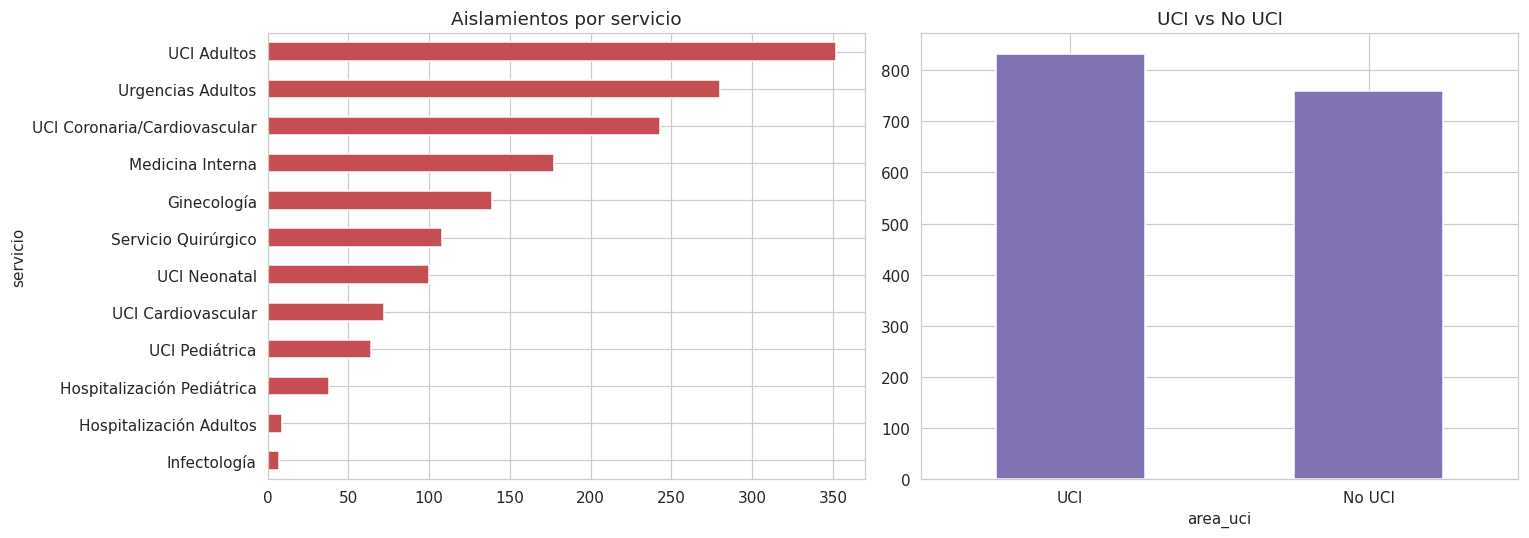

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_base_pretratada["servicio"].value_counts().plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].invert_yaxis()
axes[0].set_title("Aislamientos por servicio")

df_base_pretratada["area_uci"].value_counts().plot(kind="bar", ax=axes[1], color="#8172B2")
axes[1].set_title("UCI vs No UCI")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### 4.3 Año, tipo de muestra, tipo de microorganismo

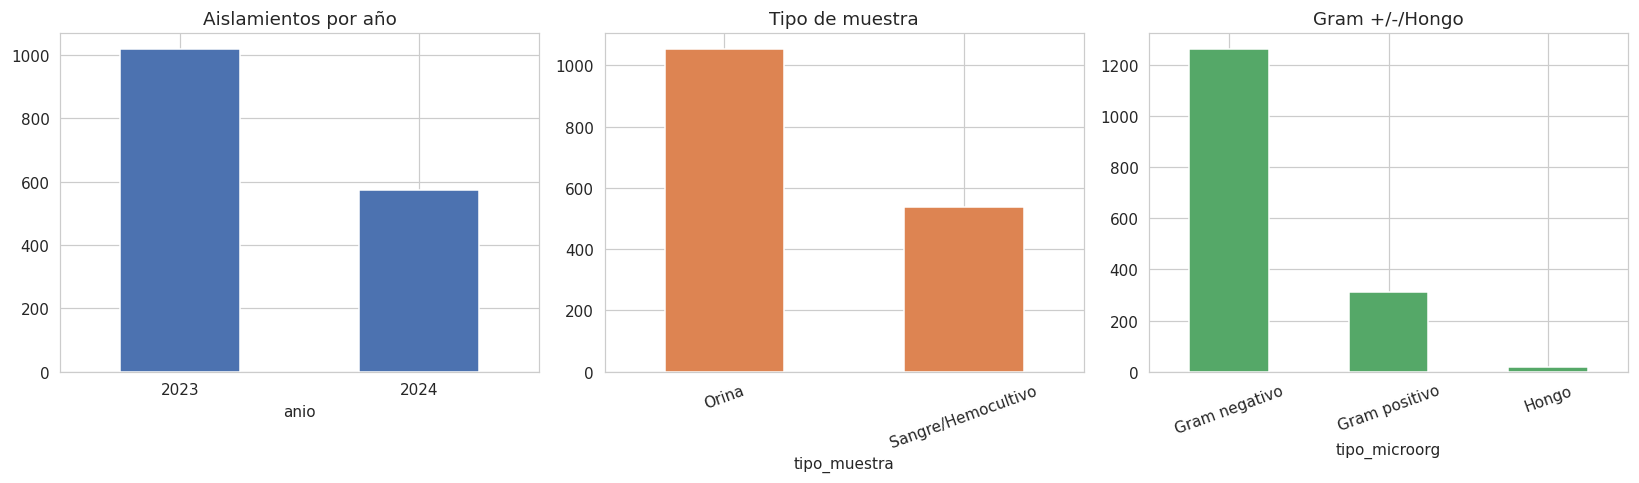

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
df_base_pretratada["anio"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Aislamientos por año"); axes[0].tick_params(axis="x", rotation=0)

df_base_pretratada["tipo_muestra"].value_counts().plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Tipo de muestra"); axes[1].tick_params(axis="x", rotation=20)

df_base_pretratada["tipo_microorg"].value_counts().plot(kind="bar", ax=axes[2], color="#55A868")
axes[2].set_title("Gram +/-/Hongo"); axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### 4.4 Estacionalidad mensual

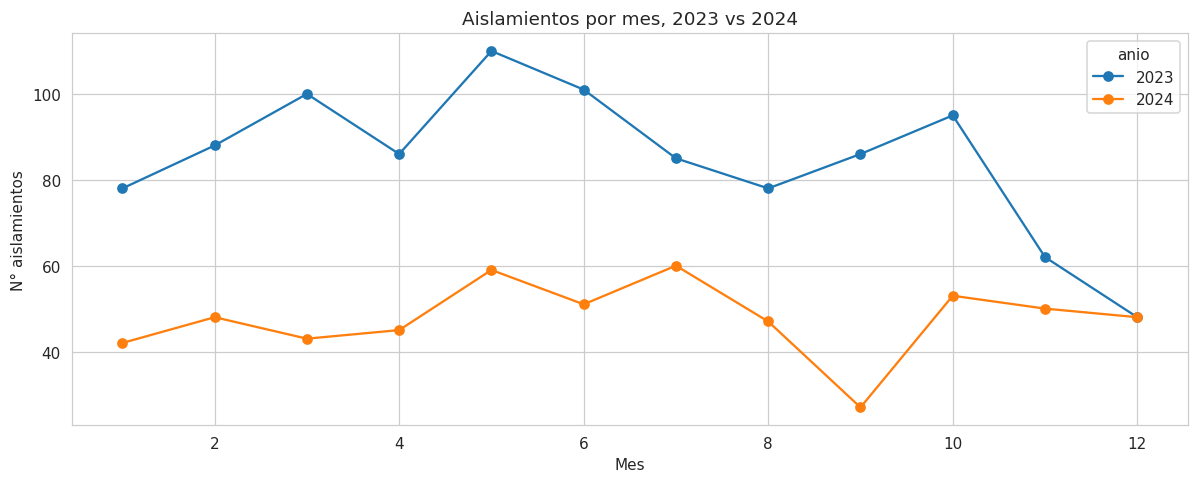

In [59]:
fig, ax = plt.subplots(figsize=(11, 4.5))
pd.crosstab(df_base_pretratada["mes"], df_base_pretratada["anio"]).plot(kind="line", marker="o", ax=ax)
ax.set_xlabel("Mes"); ax.set_ylabel("N° aislamientos")
ax.set_title("Aislamientos por mes, 2023 vs 2024")
plt.tight_layout()
plt.show()

## 5. Variables numéricas derivadas: distribución y outliers

In [60]:
NUM_VARS = ["n_testeados", "n_resistentes", "n_sensibles",
            "n_intermedios", "pct_resistencia", "n_clases_resistentes"]

df_base_pretratada[NUM_VARS].describe().round(1)

,n_testeados,n_resistentes,n_sensibles,n_intermedios,pct_resistencia,n_clases_resistentes
count,1590.0,1590.0,1590.0,1590.0,1520.0,1590.0
mean,11.6,2.3,9.0,0.3,19.6,1.9
std,3.0,2.8,3.5,0.5,22.2,2.1
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,12.0,0.0,7.0,0.0,0.0,0.0
50%,12.0,1.0,10.0,0.0,11.1,1.0
75%,13.0,3.0,12.0,0.0,30.0,3.0
max,18.0,15.0,14.0,3.0,100.0,10.0


### 5.1 Histogramas

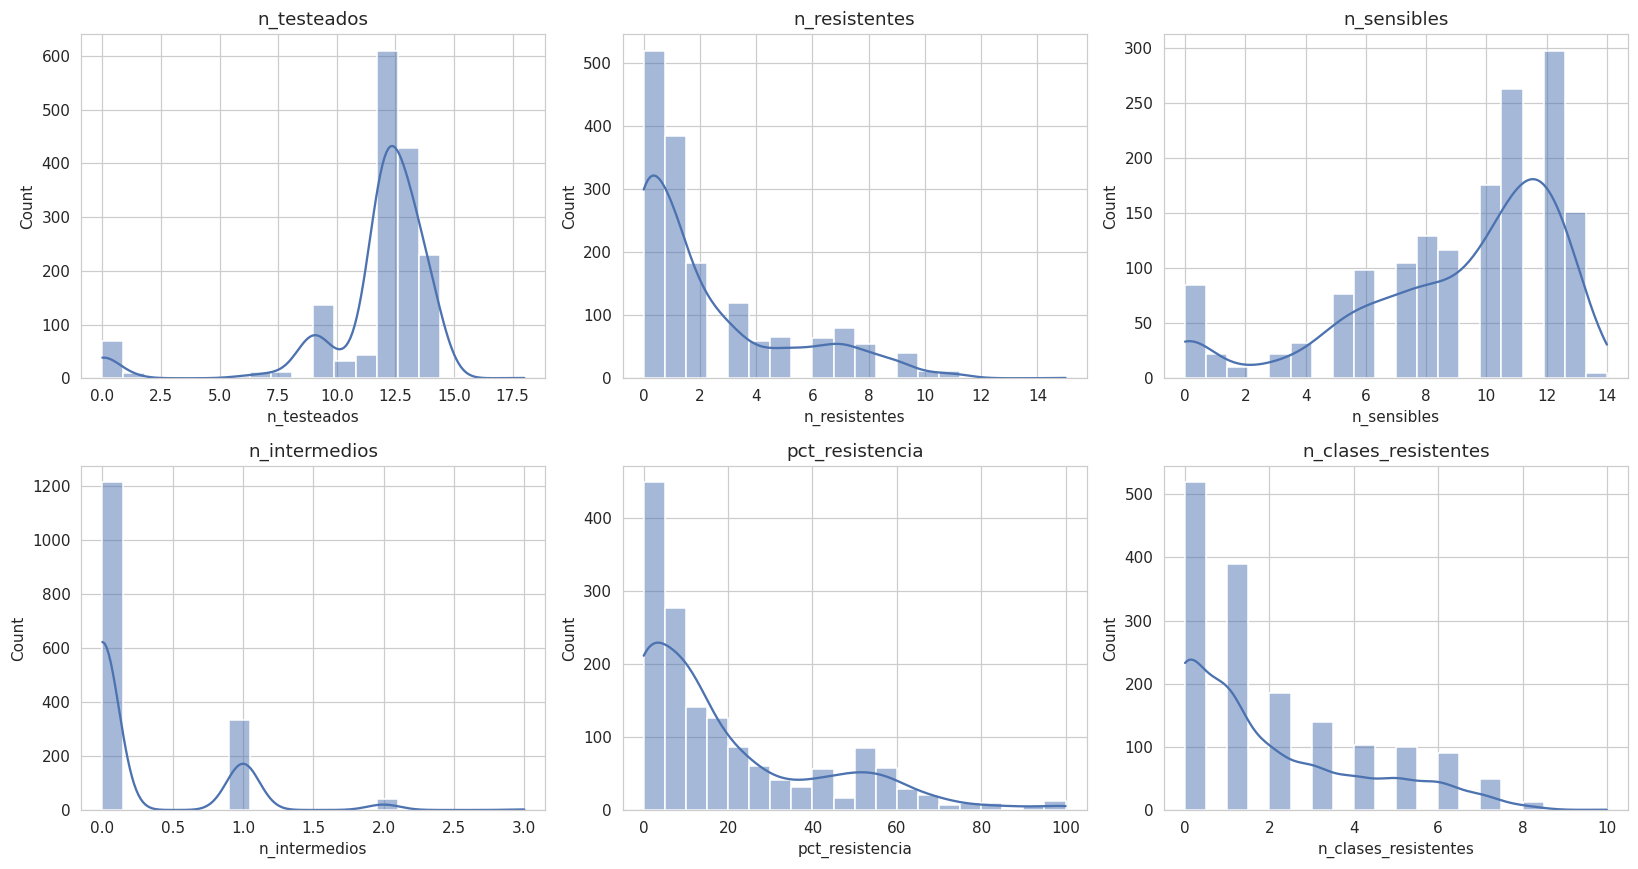

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, NUM_VARS):
    sns.histplot(df_base_pretratada[col].dropna(), bins=20, ax=ax, color="#4C72B0", kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 5.2 Boxplots y detección de outliers (regla IQR)

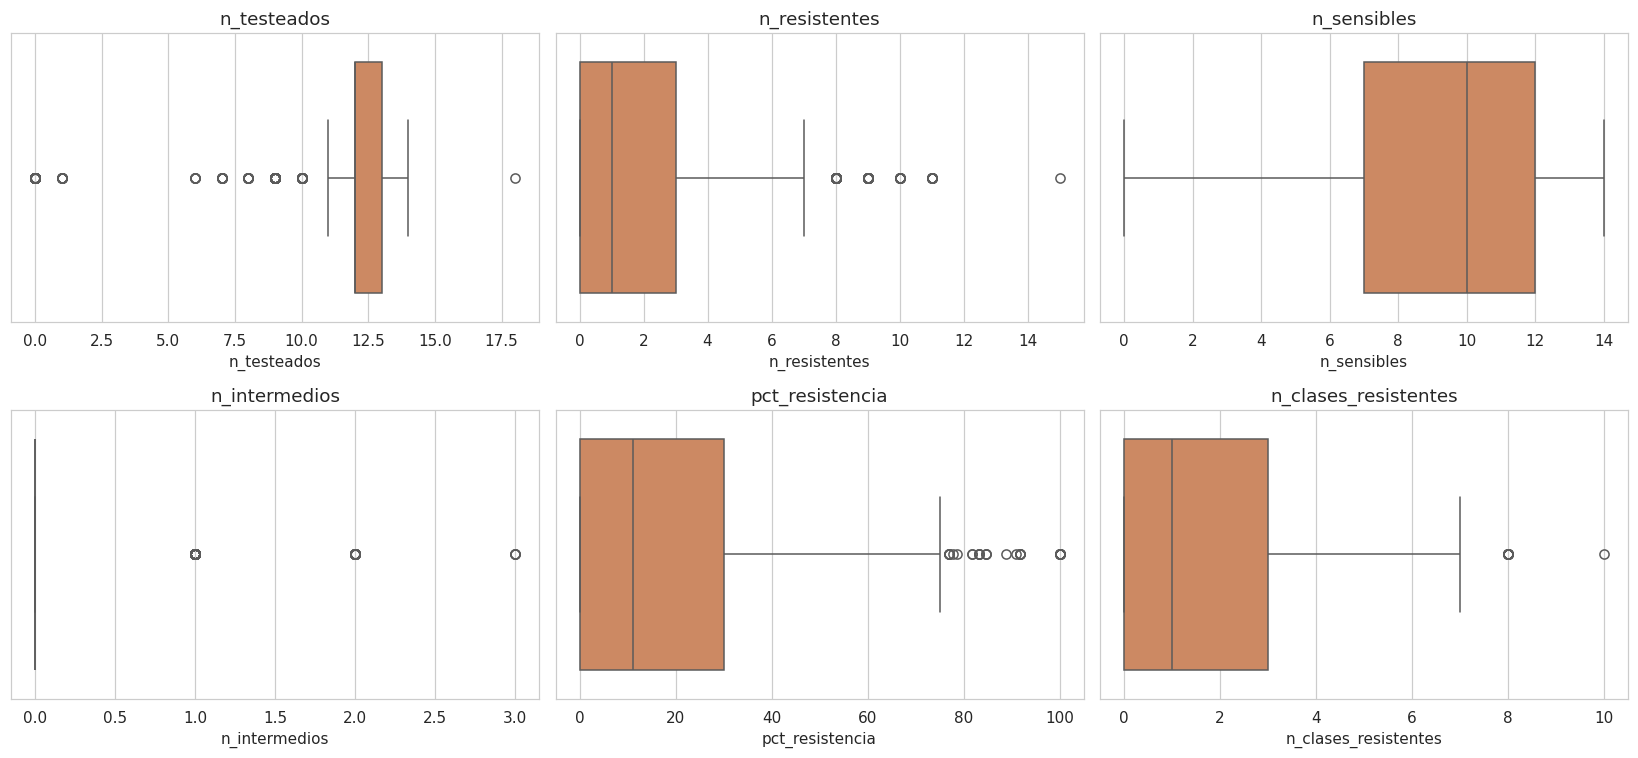

Resumen de outliers por variable (criterio IQR 1.5x):
n_testeados            límites IQR=[10.5, 14.5]  outliers=278 (17.5%)
n_resistentes          límites IQR=[-4.5, 7.5]  outliers=118 (7.4%)
n_sensibles            límites IQR=[-0.5, 19.5]  outliers=0 (0.0%)
n_intermedios          límites IQR=[0.0, 0.0]  outliers=377 (23.7%)
pct_resistencia        límites IQR=[-45.0, 75.0]  outliers=35 (2.3%)
n_clases_resistentes   límites IQR=[-4.5, 7.5]  outliers=14 (0.9%)


In [62]:
def resumen_outliers_iqr(serie, nombre):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = serie[(serie < lo) | (serie > hi)]
    print(f"{nombre:22s} límites IQR=[{lo:.1f}, {hi:.1f}]  outliers={len(outliers)} "
          f"({len(outliers)/serie.notna().sum()*100:.1f}%)")
    return outliers

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, NUM_VARS):
    sns.boxplot(x=df_base_pretratada[col], ax=ax, color="#DD8452")
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("Resumen de outliers por variable (criterio IQR 1.5x):")
for col in NUM_VARS:
    resumen_outliers_iqr(df_base_pretratada[col], col)

### 5.3 Inspección de los outliers extremos

In [63]:
q1, q3 = df_base_pretratada["pct_resistencia"].quantile([0.25, 0.75])
iqr = q3 - q1
umbral_alto = q3 + 1.5 * iqr

extremos = df_base_pretratada[df_base_pretratada["pct_resistencia"] >= umbral_alto].sort_values(
    "pct_resistencia", ascending=False)

print(f"Aislamientos con % resistencia >= {umbral_alto:.1f}% (n={len(extremos)}):")
extremos[["num_muestra", "microorganismo", "servicio", "anio",
          "n_testeados", "n_resistentes", "pct_resistencia", "MDR"]].head(20)

Aislamientos con % resistencia >= 75.0% (n=37):


,num_muestra,microorganismo,servicio,anio,n_testeados,n_resistentes,pct_resistencia,MDR
708,0267902-MV,Pseudomonas aeruginosa,Servicio Quirúrgico,2023,11,11,100.0,MDR
719,0211274-MV,Pseudomonas aeruginosa,Medicina Interna,2023,9,9,100.0,MDR
725,0271047-HC1,Pseudomonas aeruginosa,UCI Adultos,2023,9,9,100.0,MDR
718,0239692-HC3,Pseudomonas aeruginosa,UCI Adultos,2023,9,9,100.0,MDR
713,0226658-HC1,Pseudomonas aeruginosa,Medicina Interna,2023,9,9,100.0,MDR
1346,0370612-OC,Pseudomonas aeruginosa,Medicina Interna,2024,9,9,100.0,MDR
1140,0325683-HC1,Pseudomonas aeruginosa,UCI Adultos,2024,9,9,100.0,MDR
1573,0421198-HC1,Pseudomonas aeruginosa,UCI Adultos,2024,11,11,100.0,MDR
1400,0372491-OC,Pseudomonas aeruginosa,UCI Adultos,2024,11,11,100.0,MDR
767,0261818-OC,Pseudomonas aeruginosa,UCI Coronaria/Cardiovascular,2023,9,9,100.0,MDR


### 5.4 Relación n_testeados vs n_resistentes (¿el % de resistencia depende de cuánto se testeó?)

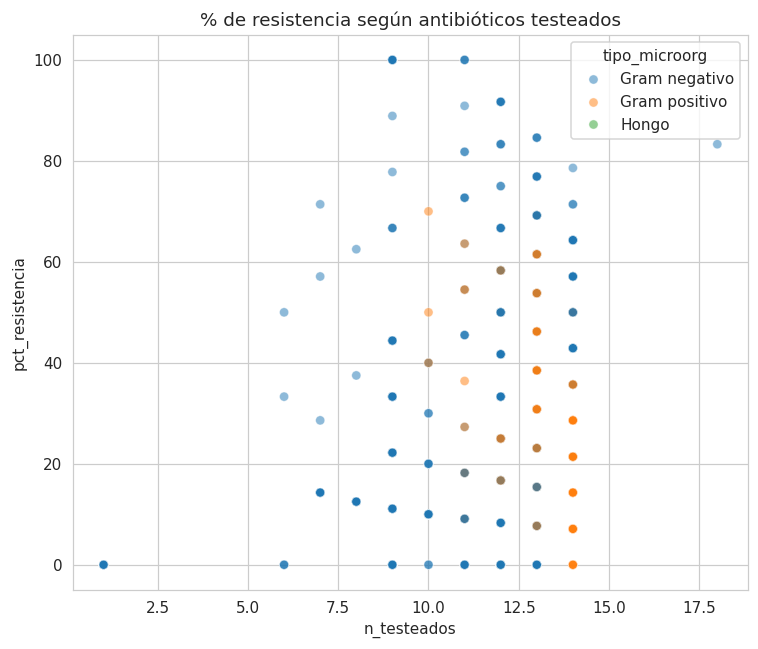

In [64]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=df_base_pretratada, x="n_testeados", y="pct_resistencia",
                 hue="tipo_microorg", alpha=0.5, ax=ax)
ax.set_title("% de resistencia según antibióticos testeados")
plt.tight_layout()
plt.show()

## 6. Distribución de MDR (fenotipo clave del análisis)

Distribución MDR (incluye 'No evaluable'):
MDR
No MDR          1015
MDR              495
No evaluable      61
Name: count, dtype: int64

% MDR entre aislamientos evaluables:
MDR
No MDR    67.2
MDR       32.8
Name: proportion, dtype: float64


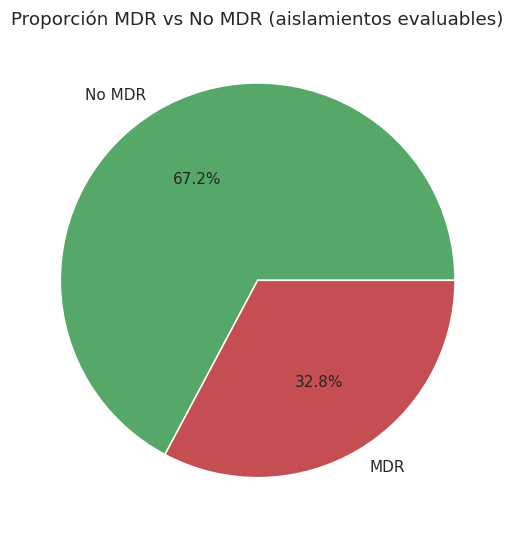

In [65]:
# Excluir hongos (MDR no aplica) y "No evaluable" para el % real
df_bact = df_base_pretratada[df_base_pretratada["tipo_microorg"] != "Hongo"].copy()

print("Distribución MDR (incluye 'No evaluable'):")
print(df_bact["MDR"].value_counts())

print("\n% MDR entre aislamientos evaluables:")
evaluables = df_bact[df_bact["MDR"] != "No evaluable"]
print((evaluables["MDR"].value_counts(normalize=True) * 100).round(1))

fig, ax = plt.subplots(figsize=(6, 5))
evaluables["MDR"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax,
                                       colors=["#55A868", "#C44E52"])
ax.set_ylabel("")
ax.set_title("Proporción MDR vs No MDR (aislamientos evaluables)")
plt.tight_layout()
plt.show()

### 6.1 MDR por microorganismo (top especies)

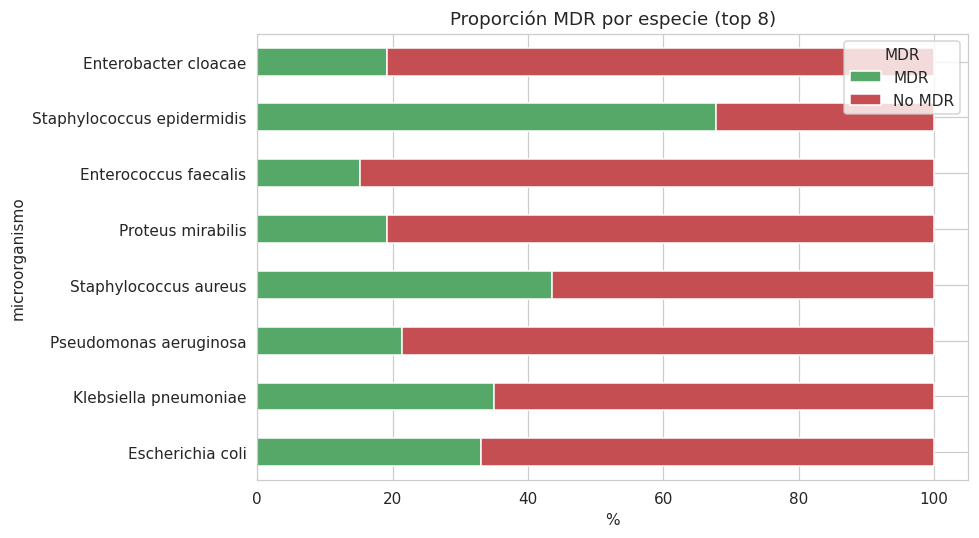

MDR,MDR,No MDR
microorganismo,,
Escherichia coli,33.1,66.9
Klebsiella pneumoniae,35.0,65.0
Pseudomonas aeruginosa,21.4,78.6
Staphylococcus aureus,43.6,56.4
Proteus mirabilis,19.1,80.9
Enterococcus faecalis,15.1,84.9
Staphylococcus epidermidis,67.8,32.2
Enterobacter cloacae,19.2,80.8


In [66]:
top8 = df_bact["microorganismo"].value_counts().head(8).index
sub = evaluables[evaluables["microorganismo"].isin(top8)]

tab_mdr = pd.crosstab(sub["microorganismo"], sub["MDR"], normalize="index") * 100
tab_mdr = tab_mdr.reindex(top8)

fig, ax = plt.subplots(figsize=(9, 5))
tab_mdr.plot(kind="barh", stacked=True, ax=ax, color=["#55A868", "#C44E52"])
ax.set_xlabel("%")
ax.set_title("Proporción MDR por especie (top 8)")
plt.tight_layout()
plt.show()

tab_mdr.round(1)

### 6.2 MDR por área (UCI vs No UCI)

MDR        MDR  No MDR
area_uci              
No UCI    30.1    69.9
UCI       35.3    64.7


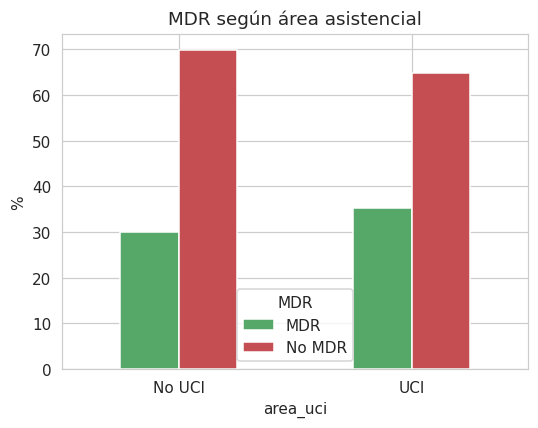

In [67]:
tab_uci = pd.crosstab(evaluables["area_uci"], evaluables["MDR"], normalize="index") * 100
print(tab_uci.round(1))

fig, ax = plt.subplots(figsize=(5, 4))
tab_uci.plot(kind="bar", ax=ax, color=["#55A868", "#C44E52"])
ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=0)
ax.set_title("MDR según área asistencial")
plt.tight_layout()
plt.show()

## 7. Matriz de correlación exploratoria (variables numéricas)

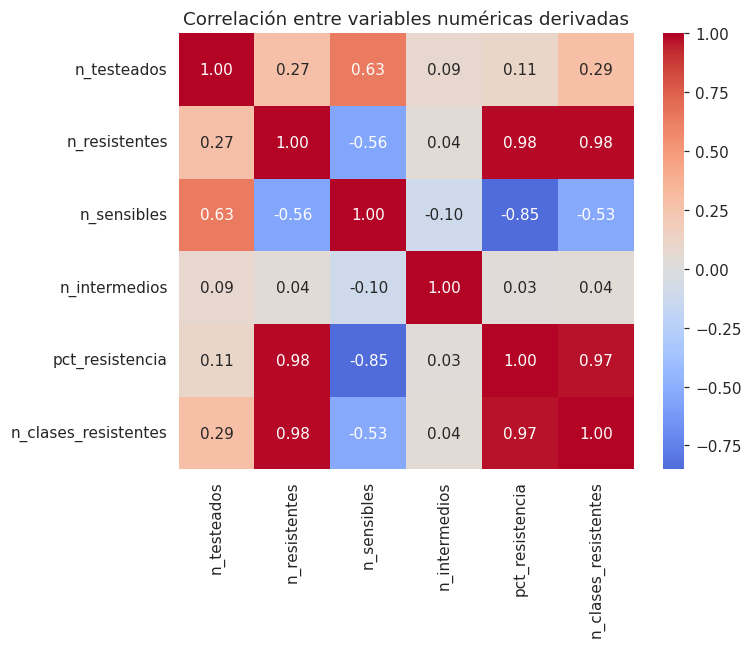

In [68]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = df_base_pretratada[NUM_VARS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación entre variables numéricas derivadas")
plt.tight_layout()
plt.show()

## 8. Resumen ejecutivo del EDA

In [69]:
print("="*65)
print("RESUMEN EDA — base_pretratada_RAM_Magdalena")
print("="*65)
print(f"Aislamientos totales        : {len(df_base_pretratada)}")
print(f"  Bacterias                 : {(df_base_pretratada['tipo_microorg']!='Hongo').sum()}")
print(f"  Hongos (excluir de MDR)   : {(df_base_pretratada['tipo_microorg']=='Hongo').sum()}")
print(f"Antibióticos evaluados      : {len(ANTIBIOTICOS)}")
print(f"Microorganismos distintos   : {df_base_pretratada['microorganismo'].nunique()}")
print(f"Servicios distintos         : {df_base_pretratada['servicio'].nunique()}")
print(f"% MDR (evaluables)          : "
      f"{(evaluables['MDR']=='MDR').mean()*100:.1f}%")
print(f"Outliers pct_resistencia    : {len(extremos)} "
      f"({len(extremos)/df_base_pretratada['pct_resistencia'].notna().sum()*100:.1f}%)")
print("\n✓ EDA completo. Comparte estos resultados para pasar a la Parte 3:")
print("  tabla sociodemográfica → análisis general → descriptivo-analítico (MDR/co-resistencia).")

RESUMEN EDA — base_pretratada_RAM_Magdalena
Aislamientos totales        : 1590
  Bacterias                 : 1571
  Hongos (excluir de MDR)   : 19
Antibióticos evaluados      : 38
Microorganismos distintos   : 21
Servicios distintos         : 12
% MDR (evaluables)          : 32.8%
Outliers pct_resistencia    : 37 (2.4%)

✓ EDA completo. Comparte estos resultados para pasar a la Parte 3:
  tabla sociodemográfica → análisis general → descriptivo-analítico (MDR/co-resistencia).
